In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCurve = np.genfromtxt('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/HEPData-ins1894408-v2-csv/2Dexclusioncontour,fermionportal,Observed.csv',
                        skip_header=9,names=True,delimiter=',')

In [3]:
print(cmsCurve.dtype.names)

('m_Phi_GeV', 'm_chi_GeV')


In [4]:
# inputFiles = ['../../CMS-EXO-20-004/scanResults_S3D_uR_CMS_BPs_nocut.pcl']
inputFiles = ['../../t-channel/notebooks/scanResults_S3D_uR_combined_1j2j.pcl']
dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [5]:
models = []
mCols = ['$m_{med}$','$m_{DM}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0]}



In [7]:
# Remove duplicated data from other datasets
recastData = recastData[recastData['Data-takingperiod'] == 2017]

In [10]:
recastData = recastData[~np.isnan(recastData['$\mu^{UL}_{obs}$'])]

In [11]:
recastData

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,bin_1160.0_1250.0_ErrorMinus,bin_1250.0_1400.0,bin_1250.0_1400.0_ErrorPlus,bin_1250.0_1400.0_ErrorMinus,$\lambda$,Total MC Events,Total xsec-pT150 (pb),Total xsec (pb),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,85815.947223,11911.850787,11911.850787,43017.135810,...,137.556905,137.556905,137.556905,137.556905,1.0,100000,41.145860,857.320528,0.016892,0.010454
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,28197.848152,1161.454342,1161.454342,17206.162453,...,0.000000,109.877085,63.437565,63.437565,1.0,100000,10.062331,18.327549,0.056031,0.033086
10,tchannel,DM+QCDjets,300.0,200.0,2017,41.5,6288.673735,354.441520,354.441520,4590.255477,...,14.434226,107.554842,39.754046,39.754046,1.0,100000,2.750235,7.633452,0.117055,0.058735
13,tchannel,DM+QCDjets,500.0,1.0,2017,41.5,8701.689305,244.782523,244.782523,6544.929336,...,9.429101,19.899414,11.708681,11.708681,1.0,100000,2.070805,2.519828,0.116993,0.080598
16,tchannel,DM+QCDjets,500.0,200.0,2017,41.5,5186.862981,151.917509,151.917509,3879.616456,...,6.246509,23.329982,10.029926,10.029926,1.0,100000,1.271837,1.622122,0.179137,0.125037
19,tchannel,DM+QCDjets,500.0,400.0,2017,41.5,777.494876,34.610610,34.610610,579.751867,...,2.338276,9.143808,3.555388,3.555388,1.0,100000,0.282820,0.580635,0.716821,0.428588
22,tchannel,DM+QCDjets,750.0,1.0,2017,41.5,1097.021123,36.302882,36.302882,1228.346755,...,3.686923,11.338083,3.686923,3.686923,1.0,100000,0.390303,0.439379,0.193298,0.132138
25,tchannel,DM+QCDjets,750.0,200.0,2017,41.5,981.756210,29.171904,29.171904,972.681425,...,2.590004,11.993537,3.231464,3.231464,1.0,100000,0.286466,0.317554,0.279797,0.161894
28,tchannel,DM+QCDjets,750.0,400.0,2017,41.5,602.946611,17.540292,17.540292,561.986196,...,1.733153,3.607307,1.320172,1.320172,1.0,100000,0.161365,0.186374,0.625492,0.398620
31,tchannel,DM+QCDjets,750.0,550.0,2017,41.5,322.789965,10.088941,10.088941,258.126659,...,0.589830,2.982225,0.954199,0.954199,1.0,100000,0.086079,0.114837,1.723781,1.173997


In [27]:
kfactor = 1.
lmuData = np.log10(recastData['$\mu^{UL}_{obs}$']/kfactor)

/tmp/ipykernel_220800/3270980453.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)


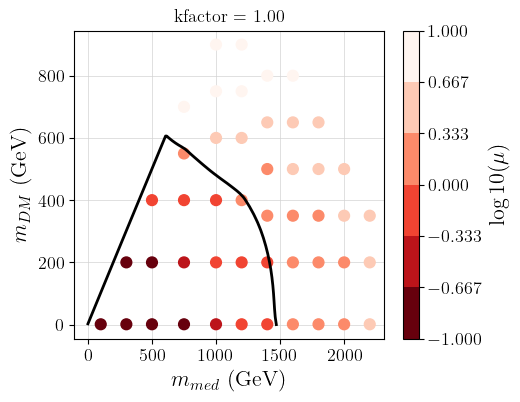

In [28]:
plt.scatter(x=recastData['$m_{med}$'],y=recastData['$m_{DM}$'],vmin=-1.0,vmax=1.0,
            c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)
cbar = plt.colorbar(label=r'$\log10(\mu)$')
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
plt.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.ylabel(r'$m_{DM}$ (GeV)')
# plt.ylim(-10,1400)
# plt.xlim(0,3100)
plt.title('kfactor = %1.2f' %kfactor)
plt.text(0.04,0.75,textstr,fontsize=16,bbox=dict(facecolor='none', edgecolor='black'),
         transform = plt.gca().transAxes)
plt.show()

In [29]:
pts = np.array([x for x in product(np.linspace(0.,2000.,300),np.linspace(0.,1000.,300))])
lmuPts = griddata(list(zip(recastData['$m_{med}$'],recastData['$m_{DM}$'])),
                  lmuData,pts)
pts = pts[~np.isnan(lmuPts)]
lmuPts = lmuPts[~np.isnan(lmuPts)]

/tmp/ipykernel_220800/3054737756.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))
/tmp/ipykernel_220800/3054737756.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].set_label('kfactor = %1.2f' %kfactor)


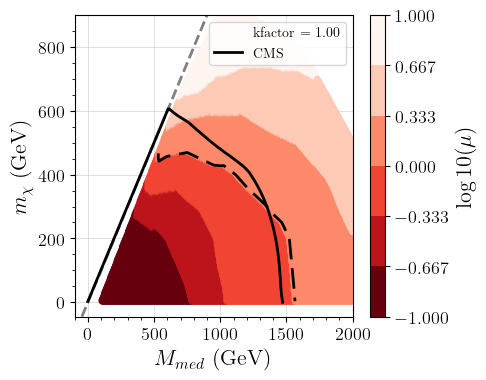

In [30]:
fig,ax = plt.subplots()

p = ax.scatter(x=pts[:,0],y=pts[:,1],vmin=-1.0,vmax=1.0,
            c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))
cbar = plt.colorbar(p,label=r'$\log10(\mu)$',ax=ax)
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
cs = ax.tricontour(pts[:,0],pts[:,1],lmuPts,levels=[0.0],
               linewidths=2,linestyles='--',colors='black')
cs.collections[0].set_label('kfactor = %1.2f' %kfactor)

ax.axline((1, 1), slope=1, linestyle='--', color='gray')

ax.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
ax.legend(loc='upper right')
ax.set_xlabel(r'$M_{med}$ (GeV)')
ax.set_ylabel(r'$m_{\chi}$ (GeV)')
# ax.set_ylim(10,1400)
# ax.set_xlim(10,3000)
ax.minorticks_on()
ax.text(0.05,0.75,textstr,fontsize=14,bbox=dict(facecolor='white'),
         transform = ax.transAxes)
# ax[0].set_title('kfactor = %1.2f' %kfactor)

plt.tight_layout()

plt.show()

In [31]:
pd.read_pickle('/home/camila/MG5/DMSimpt_S3D_uR_1j2j/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,110.235906,129.674547,144.849228
bin_250.0_280.0_ErrorPlus,2.62914,2.855674,3.013771
bin_250.0_280.0_ErrorMinus,2.62914,2.855674,3.013771
bin_280.0_310.0,91.988666,104.404314,118.199479
bin_280.0_310.0_ErrorPlus,2.404975,2.560189,2.726779
bin_280.0_310.0_ErrorMinus,2.404975,2.560189,2.726779
bin_310.0_340.0,73.866836,87.097653,97.882963
bin_310.0_340.0_ErrorPlus,2.153998,2.336982,2.477454


In [32]:
recastData[recastData['$m_{DM}$']==550].T

,31
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,750.0
$m_{DM}$,550.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,322.789965
bin_250.0_280.0_ErrorPlus,10.088941
bin_250.0_280.0_ErrorMinus,10.088941
bin_280.0_310.0,258.126659
